## INSTALL AND IMPORT LIBRARIES

In [ ]:
!pip install shap --quiet
!pip install category_encoders --quiet
!pip install statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


## Scikit-learn

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, classification_report,
    precision_recall_curve
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost


In [ ]:
from xgboost import XGBClassifier

# TensorFlow/Keras for ANN


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Category encoders for target encoding


In [ ]:
import category_encoders as ce

# Statistical testing


In [ ]:
from scipy.stats import wilcoxon

# Set random seeds for full reproducibility


In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


print(f"\n✅ All libraries imported successfully")
print(f"   Pandas:     {pd.__version__}")
print(f"   NumPy:      {np.__version__}")
print(f"   TensorFlow: {tf.__version__}")



✅ All libraries imported successfully
   Pandas:     2.2.2
   NumPy:      2.0.2
   TensorFlow: 2.20.0


# LOAD AND PROFILE DATASET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/KaggleV2-May-2016.csv')

print(f"✅ Records: {df.shape[0]:,}")
print(f"✅ Columns: {df.shape[1]}")
print(f"✅ Column names: {df.columns.tolist()}")
print(f"\nTarget variable:")
print(df['No-show'].value_counts())

✅ Records: 110,527
✅ Columns: 14
✅ Column names: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']

Target variable:
No-show
No     88208
Yes    22319
Name: count, dtype: int64


In [ ]:
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"\n  Total records:   {df.shape[0]:,}")
print(f"  Total features:  {df.shape[1]}")
print(f"\nColumn names and data types:")
print(df.dtypes)
print(f"\nTarget variable distribution:")
print(df['No-show'].value_counts())
print(f"\nNo-show rate: {(df['No-show']=='Yes').sum()/len(df)*100:.2f}%")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nBasic statistics:")
print(df.describe())
print(f"\n⚠️  Records with negative age: {(df['Age'] < 0).sum()}")

DATASET LOADED SUCCESSFULLY

  Total records:   110,527
  Total features:  14

Column names and data types:
PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object

Target variable distribution:
No-show
No     88208
Yes    22319
Name: count, dtype: int64

No-show rate: 20.19%

Missing values per column:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

Basic statistics:
          PatientId  AppointmentID            Age    Scholars

## DATA CLEANING AND FEATURE ENGINEERING

In [ ]:
# CELL 3 — COMPLETE DATA CLEANING AND FEATURE ENGINEERING
from sklearn.preprocessing import LabelEncoder

df_clean = df.copy()

# 1. Remove negative age
df_clean = df_clean[df_clean['Age'] >= 0].reset_index(drop=True)
print(f"✅ Removed negative age — dataset: {len(df_clean):,} records")

# 2. Drop identifier columns
df_clean = df_clean.drop(['PatientId', 'AppointmentID'], axis=1)
print("✅ Dropped PatientId and AppointmentID")

# 3. Convert dates to datetime
df_clean['ScheduledDay'] = pd.to_datetime(df_clean['ScheduledDay'])
df_clean['AppointmentDay'] = pd.to_datetime(df_clean['AppointmentDay'])
print("✅ Converted date columns to datetime")

# 4. Feature Engineering
df_clean['WaitDays'] = (
    df_clean['AppointmentDay'] - df_clean['ScheduledDay']
).dt.days
df_clean['ScheduledHour'] = df_clean['ScheduledDay'].dt.hour
df_clean['AppointmentDayOfWeek'] = df_clean['AppointmentDay'].dt.dayofweek
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[0, 12, 17, 35, 50, 65, 120],
    labels=['Child', 'Teen', 'Young Adult',
            'Adult', 'Middle Aged', 'Senior']
)
print("✅ Created WaitDays, ScheduledHour, AppointmentDayOfWeek, AgeGroup")

# 5. Encode target variable
df_clean['NoShow_Binary'] = (df_clean['No-show'] == 'Yes').astype(int)
print("✅ Encoded target variable (0=Attended, 1=No-show)")

# 6. Label encode Gender
le_gender = LabelEncoder()
df_clean['Gender_Encoded'] = le_gender.fit_transform(df_clean['Gender'])
print("✅ Label encoded Gender")



✅ Removed negative age — dataset: 110,526 records
✅ Dropped PatientId and AppointmentID
✅ Converted date columns to datetime
✅ Created WaitDays, ScheduledHour, AppointmentDayOfWeek, AgeGroup
✅ Encoded target variable (0=Attended, 1=No-show)
✅ Label encoded Gender


In [ ]:
# 7. Confirm all columns exist
print(f"\nAll columns in df_clean:")
print(df_clean.columns.tolist())

print(f"\ndf_clean shape: {df_clean.shape}")
print(f"\nSample of new features:")
print(df_clean[['Age', 'AgeGroup', 'WaitDays', 'ScheduledHour',
                 'AppointmentDayOfWeek', 'Gender_Encoded',
                 'NoShow_Binary']].head(5).to_string())


All columns in df_clean:
['Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show', 'WaitDays', 'ScheduledHour', 'AppointmentDayOfWeek', 'AgeGroup', 'NoShow_Binary', 'Gender_Encoded']

df_clean shape: (110526, 18)

Sample of new features:
   Age     AgeGroup  WaitDays  ScheduledHour  AppointmentDayOfWeek  Gender_Encoded  NoShow_Binary
0   62  Middle Aged        -1             18                     4               0              0
1   56  Middle Aged        -1             16                     4               1              0
2   62  Middle Aged        -1             16                     4               0              0
3    8        Child        -1             17                     4               0              0
4   56  Middle Aged        -1             16                     4               0              0


DEFINE FEATURES AND SPLIT DATA

In [ ]:
base_features = [
    'Age', 'Gender_Encoded', 'Scholarship', 'Hipertension',
    'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received',
    'WaitDays', 'ScheduledHour', 'AppointmentDayOfWeek'
]

X_base = df_clean[base_features].copy()
X_neighbourhood = df_clean['Neighbourhood'].copy()
y = df_clean['NoShow_Binary'].copy()


print("DATA SPLITTING — 70% Train / 15% Validation / 15% Test")


DATA SPLITTING — 70% Train / 15% Validation / 15% Test


In [ ]:
# First split: 70% train, 30% temp
X_base_train, X_base_temp, X_nb_train, X_nb_temp, y_train, y_temp = \
    train_test_split(
        X_base, X_neighbourhood, y,
        test_size=0.30, random_state=SEED, stratify=y
    )

# Second split: 15% validation, 15% test
X_base_val, X_base_test, X_nb_val, X_nb_test, y_val, y_test = \
    train_test_split(
        X_base_temp, X_nb_temp, y_temp,
        test_size=0.50, random_state=SEED, stratify=y_temp
    )

In [ ]:
print(f"\n  Training set:   {len(y_train):,} records ({len(y_train)/len(y)*100:.1f}%)")
print(f"  Validation set: {len(y_val):,} records ({len(y_val)/len(y)*100:.1f}%)")
print(f"  Test set:       {len(y_test):,} records ({len(y_test)/len(y)*100:.1f}%)")


  Training set:   77,368 records (70.0%)
  Validation set: 16,579 records (15.0%)
  Test set:       16,579 records (15.0%)


In [ ]:
#Target encode Neighbourhood AFTER splitting
# Fit on training set only — transform val and test
print("\n  Applying target encoding to Neighbourhood (fit on train only)...")
te = ce.TargetEncoder(cols=['Neighbourhood'], smoothing=1.0)

X_nb_train_enc = te.fit_transform(
    X_nb_train.to_frame(), y_train
).rename(columns={'Neighbourhood': 'Neighbourhood_Encoded'})

X_nb_val_enc = te.transform(
    X_nb_val.to_frame()
).rename(columns={'Neighbourhood': 'Neighbourhood_Encoded'})

X_nb_test_enc = te.transform(
    X_nb_test.to_frame()
).rename(columns={'Neighbourhood': 'Neighbourhood_Encoded'})


  Applying target encoding to Neighbourhood (fit on train only)...


In [ ]:
# Combine base features with encoded neighbourhood
X_train = pd.concat([X_base_train.reset_index(drop=True),
                      X_nb_train_enc.reset_index(drop=True)], axis=1)
X_val = pd.concat([X_base_val.reset_index(drop=True),
                    X_nb_val_enc.reset_index(drop=True)], axis=1)
X_test = pd.concat([X_base_test.reset_index(drop=True),
                     X_nb_test_enc.reset_index(drop=True)], axis=1)

features = list(X_train.columns)
print(f"✅ Target encoding applied correctly (no data leakage)")
print(f"   Final feature count: {len(features)}")

✅ Target encoding applied correctly (no data leakage)
   Final feature count: 12


In [ ]:
# Normalise features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print("✅ Features normalised using MinMaxScaler (fit on train only)")

# Apply SMOTE to training set ONLY
print("\n  Applying SMOTE to training set only...")
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"✅ SMOTE applied — training set balanced:")
print(f"   Before: Attended={y_train.value_counts()[0]:,}, "
      f"No-show={y_train.value_counts()[1]:,}")
print(f"   After:  Attended={sum(y_train_res==0):,}, "
      f"No-show={sum(y_train_res==1):,}")
print(f"\n  Training class distribution:")
print(f"    Attended (0): {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"    No-show  (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")

✅ Features normalised using MinMaxScaler (fit on train only)

  Applying SMOTE to training set only...
✅ SMOTE applied — training set balanced:
   Before: Attended=61,745, No-show=15,623
   After:  Attended=61,745, No-show=61,745

  Training class distribution:
    Attended (0): 61,745 (79.8%)
    No-show  (1): 15,623 (20.2%)


## HELPER FUNCTIONS

In [ ]:
def find_optimal_threshold(model, X_val_data, y_val_data, is_keras=False):
    """Find optimal classification threshold using validation set."""
    if is_keras:
        y_prob = model.predict(X_val_data, verbose=0).flatten()
    else:
        y_prob = model.predict_proba(X_val_data)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(
        y_val_data, y_prob
    )
    f1_scores = np.where(
        (precisions + recalls) == 0, 0,
        2 * precisions * recalls / (precisions + recalls)
    )
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    return best_threshold, f1_scores[best_idx]


def evaluate_model(name, model, X_test_data, y_test_data,
                   threshold=0.5, is_keras=False):
    """Evaluate a trained model and return all six metrics."""
    if is_keras:
        y_prob = model.predict(X_test_data, verbose=0).flatten()
    else:
        y_prob = model.predict_proba(X_test_data)[:, 1]

    y_pred = (y_prob >= threshold).astype(int)

    acc  = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred, zero_division=0)
    rec  = recall_score(y_test_data, y_pred, zero_division=0)
    f1   = f1_score(y_test_data, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test_data, y_prob)
    mcc  = matthews_corrcoef(y_test_data, y_pred)

    print(f"\n{'='*55}")
    print(f"  {name} — Test Set Results (threshold={threshold:.3f})")
    print(f"{'='*55}")
    print(f"  Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  MCC:       {mcc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_data, y_pred,
                                  target_names=['Attended', 'No-Show'],
                                  zero_division=0))

    return {
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'AUC-ROC': round(auc, 4),
        'MCC': round(mcc, 4),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'threshold': threshold
    }

print("✅ Helper functions defined")

✅ Helper functions defined


## DUMMY CLASSIFIER BASELINE

In [ ]:
print("\n" + "="*60)
print("MODEL 0: DUMMY CLASSIFIER — MAJORITY CLASS BASELINE")
print("="*60)

dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_train_res, y_train_res)
results_dummy = evaluate_model(
    "Dummy Classifier", dummy, X_test_scaled, y_test
)
print("\n📌 This model always predicts Attended.")
print("   Any trained model MUST beat this to be considered useful.")


MODEL 0: DUMMY CLASSIFIER — MAJORITY CLASS BASELINE

  Dummy Classifier — Test Set Results (threshold=0.500)
  Accuracy:  0.7981  (79.81%)
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  AUC-ROC:   0.5000
  MCC:       0.0000

Classification Report:
              precision    recall  f1-score   support

    Attended       0.80      1.00      0.89     13231
     No-Show       0.00      0.00      0.00      3348

    accuracy                           0.80     16579
   macro avg       0.40      0.50      0.44     16579
weighted avg       0.64      0.80      0.71     16579


📌 This model always predicts Attended.
   Any trained model MUST beat this to be considered useful.


##  LOGISTIC REGRESSION

In [ ]:
print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*60)

lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [2000]
}

print("Running RandomizedSearchCV — 5-fold CV...")
lr_search = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', random_state=SEED),
    lr_params,
    n_iter=10,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=SEED,
    verbose=0
)
lr_search.fit(X_train_res, y_train_res)
lr_best = lr_search.best_estimator_

print(f"✅ Best parameters: {lr_search.best_params_}")
print(f"   Best CV F1:      {lr_search.best_score_:.4f}")


MODEL 1: LOGISTIC REGRESSION
Running RandomizedSearchCV — 5-fold CV...
✅ Best parameters: {'solver': 'liblinear', 'max_iter': 2000, 'C': 0.1}
   Best CV F1:      0.6074


In [ ]:
# Find optimal threshold
lr_threshold, lr_val_f1 = find_optimal_threshold(
    lr_best, X_val_scaled, y_val
)
print(f"   Optimal threshold: {lr_threshold:.3f}")
print(f"   Validation F1 at threshold: {lr_val_f1:.4f}")

   Optimal threshold: 0.480
   Validation F1 at threshold: 0.4140


In [ ]:
# Evaluate on test set
results_lr = evaluate_model(
    "Logistic Regression", lr_best,
    X_test_scaled, y_test, threshold=lr_threshold
)



  Logistic Regression — Test Set Results (threshold=0.480)
  Accuracy:  0.6324  (63.24%)
  Precision: 0.3059
  Recall:    0.6464
  F1-Score:  0.4153
  AUC-ROC:   0.6721
  MCC:       0.2234

Classification Report:
              precision    recall  f1-score   support

    Attended       0.88      0.63      0.73     13231
     No-Show       0.31      0.65      0.42      3348

    accuracy                           0.63     16579
   macro avg       0.59      0.64      0.57     16579
weighted avg       0.76      0.63      0.67     16579



In [ ]:
# Cross-validation scores
cv_scores_lr = cross_val_score(
    lr_best, X_train_res, y_train_res,
    cv=5, scoring='f1', n_jobs=-1
)
print(f"\n  5-Fold CV F1: {cv_scores_lr.mean():.4f} "
      f"(+/- {cv_scores_lr.std():.4f})")
print(f"  Individual folds: {cv_scores_lr.round(4)}")



  5-Fold CV F1: 0.6074 (+/- 0.0042)
  Individual folds: [0.6112 0.6027 0.6021 0.6086 0.6123]


## RANDOM FOREST

In [ ]:

print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST")
print("="*60)

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print("Running RandomizedSearchCV — 5-fold CV...")
print("(May take 5-10 minutes...)")

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    rf_params,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)
rf_search.fit(X_train_res, y_train_res)
rf_best = rf_search.best_estimator_

print(f"\n✅ Best parameters: {rf_search.best_params_}")
print(f"   Best CV F1:      {rf_search.best_score_:.4f}")

rf_threshold, rf_val_f1 = find_optimal_threshold(
    rf_best, X_val_scaled, y_val
)
print(f"   Optimal threshold: {rf_threshold:.3f}")

results_rf = evaluate_model(
    "Random Forest", rf_best,
    X_test_scaled, y_test, threshold=rf_threshold
)

cv_scores_rf = cross_val_score(
    rf_best, X_train_res, y_train_res,
    cv=5, scoring='f1', n_jobs=-1
)
print(f"\n  5-Fold CV F1: {cv_scores_rf.mean():.4f} "
      f"(+/- {cv_scores_rf.std():.4f})")
print(f"  Individual folds: {cv_scores_rf.round(4)}")




MODEL 2: RANDOM FOREST
Running RandomizedSearchCV — 5-fold CV...
(May take 5-10 minutes...)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
   Best CV F1:      0.8474
   Optimal threshold: 0.233

  Random Forest — Test Set Results (threshold=0.233)
  Accuracy:  0.6096  (60.96%)
  Precision: 0.3099
  Recall:    0.7608
  F1-Score:  0.4404
  AUC-ROC:   0.7270
  MCC:       0.2667

Classification Report:
              precision    recall  f1-score   support

    Attended       0.90      0.57      0.70     13231
     No-Show       0.31      0.76      0.44      3348

    accuracy                           0.61     16579
   macro avg       0.61      0.67      0.57     16579
weighted avg       0.78      0.61      0.65     16579


  5-Fold CV F1: 0.8474 (+/- 0.1117)
  Individual folds: [0.6279 0.8626 0.9185 0.9126 0.9157]


## XGBOOST

In [ ]:
print("\n" + "="*60)
print("MODEL 3: XGBOOST")
print("="*60)

# Class imbalance ratio for scale_pos_weight
neg = (y_train_res == 0).sum()
pos = (y_train_res == 1).sum()
scale_pos = neg / pos
print(f"  Scale pos weight: {scale_pos:.4f}")

xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

print("Running RandomizedSearchCV — 5-fold CV...")
print("(May take 5-10 minutes...)")

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos,
        random_state=SEED,
        eval_metric='logloss',
        use_label_encoder=False,
        tree_method='hist'
    ),
    xgb_params,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)
xgb_search.fit(X_train_res, y_train_res)
xgb_best = xgb_search.best_estimator_

print(f"\n✅ Best parameters: {xgb_search.best_params_}")
print(f"   Best CV F1:      {xgb_search.best_score_:.4f}")

xgb_threshold, xgb_val_f1 = find_optimal_threshold(
    xgb_best, X_val_scaled, y_val
)
print(f"   Optimal threshold: {xgb_threshold:.3f}")

results_xgb = evaluate_model(
    "XGBoost", xgb_best,
    X_test_scaled, y_test, threshold=xgb_threshold
)

cv_scores_xgb = cross_val_score(
    xgb_best, X_train_res, y_train_res,
    cv=5, scoring='f1', n_jobs=-1
)
print(f"\n  5-Fold CV F1: {cv_scores_xgb.mean():.4f} "
      f"(+/- {cv_scores_xgb.std():.4f})")
print(f"  Individual folds: {cv_scores_xgb.round(4)}")


MODEL 3: XGBOOST
  Scale pos weight: 1.0000
Running RandomizedSearchCV — 5-fold CV...
(May take 5-10 minutes...)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best parameters: {'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
   Best CV F1:      0.7832
   Optimal threshold: 0.445

  XGBoost — Test Set Results (threshold=0.445)
  Accuracy:  0.6354  (63.54%)
  Precision: 0.3237
  Recall:    0.7398
  F1-Score:  0.4504
  AUC-ROC:   0.7327
  MCC:       0.2809

Classification Report:
              precision    recall  f1-score   support

    Attended       0.90      0.61      0.73     13231
     No-Show       0.32      0.74      0.45      3348

    accuracy                           0.64     16579
   macro avg       0.61      0.67      0.59     16579
weighted avg       0.79      0.64      0.67     16579


  5-Fold CV F1: 0.7832 (+/- 0.1035)
  Individual folds: [0.5794 0.7995 0.8489 0.8427 0.8456]

## ARTIFICIAL NEURAL NETWORK


MODEL 4: ARTIFICIAL NEURAL NETWORK (ANN)
Trying multiple ANN configurations...

  Config 1/3: {'units_1': 128, 'units_2': 64, 'units_3': 32, 'dropout': 0.3, 'lr': 0.001}
  Validation F1: 0.4460 (threshold=0.538)

  Config 2/3: {'units_1': 256, 'units_2': 128, 'units_3': 64, 'dropout': 0.3, 'lr': 0.001}
  Validation F1: 0.4209 (threshold=0.572)

  Config 3/3: {'units_1': 128, 'units_2': 64, 'units_3': 32, 'dropout': 0.2, 'lr': 0.0005}
  Validation F1: 0.4121 (threshold=0.555)

✅ Best ANN config: {'units_1': 128, 'units_2': 64, 'units_3': 32, 'dropout': 0.3, 'lr': 0.001}
   Best validation F1: 0.4460

  ANN — Test Set Results (threshold=0.538)
  Accuracy:  0.6285  (62.85%)
  Precision: 0.3195
  Recall:    0.7428
  F1-Score:  0.4468
  AUC-ROC:   0.7287
  MCC:       0.2754

Classification Report:
              precision    recall  f1-score   support

    Attended       0.90      0.60      0.72     13231
     No-Show       0.32      0.74      0.45      3348

    accuracy                   

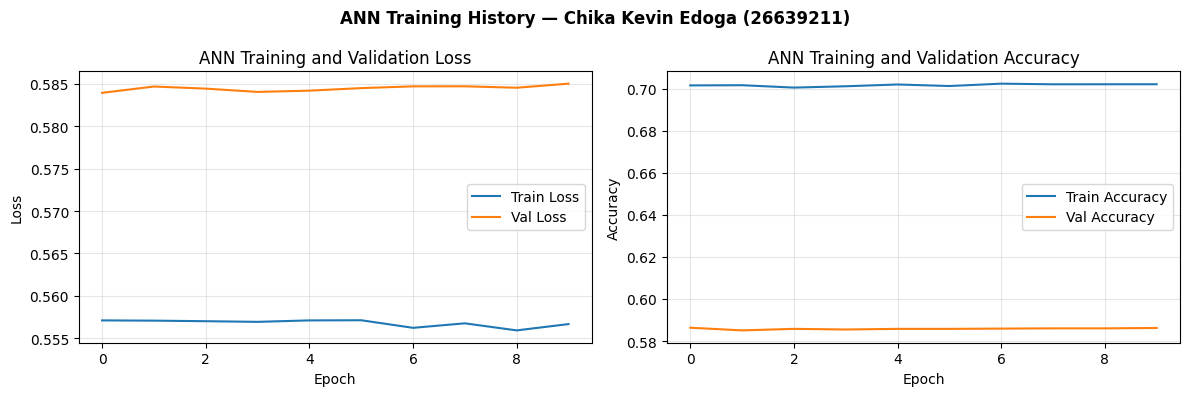

✅ ANN training history saved


In [ ]:

print("\n" + "="*60)
print("MODEL 4: ARTIFICIAL NEURAL NETWORK (ANN)")
print("="*60)

n_features = X_train_res.shape[1]

# Class weights for ANN
class_weight_ann = {
    0: 1.0,
    1: (y_train_res == 0).sum() / (y_train_res == 1).sum()
}

def build_ann(units_1=128, units_2=64, units_3=32,
              dropout=0.3, lr=0.001):
    model = Sequential([
        Dense(units_1, activation='relu',
              input_shape=(n_features,)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(units_2, activation='relu'),
        BatchNormalization(),
        Dropout(dropout),
        Dense(units_3, activation='relu'),
        Dropout(dropout / 2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Try multiple configurations and pick best on validation F1
print("Trying multiple ANN configurations...")
ann_configs = [
    {'units_1': 128, 'units_2': 64, 'units_3': 32,
     'dropout': 0.3, 'lr': 0.001},
    {'units_1': 256, 'units_2': 128, 'units_3': 64,
     'dropout': 0.3, 'lr': 0.001},
    {'units_1': 128, 'units_2': 64, 'units_3': 32,
     'dropout': 0.2, 'lr': 0.0005},
]

best_ann = None
best_ann_val_f1 = 0
best_ann_config = None

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                   restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                       patience=5, verbose=0)
]

for i, config in enumerate(ann_configs):
    print(f"\n  Config {i+1}/{len(ann_configs)}: {config}")
    model = build_ann(**config)
    history = model.fit(
        X_train_res, y_train_res,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=256,
        callbacks=callbacks,
        class_weight=class_weight_ann,
        verbose=0
    )
    threshold, val_f1 = find_optimal_threshold(
        model, X_val_scaled, y_val, is_keras=True
    )
    print(f"  Validation F1: {val_f1:.4f} (threshold={threshold:.3f})")

    if val_f1 > best_ann_val_f1:
        best_ann_val_f1 = val_f1
        best_ann = model
        best_ann_config = config
        best_ann_threshold = threshold

print(f"\n✅ Best ANN config: {best_ann_config}")
print(f"   Best validation F1: {best_ann_val_f1:.4f}")

results_ann = evaluate_model(
    "ANN", best_ann, X_test_scaled, y_test,
    threshold=best_ann_threshold, is_keras=True
)

# Plot ANN training history
plt.figure(figsize=(12, 4))
history_final = best_ann.fit(
    X_train_res, y_train_res,
    validation_data=(X_val_scaled, y_val),
    epochs=100, batch_size=256,
    callbacks=callbacks,
    class_weight=class_weight_ann,
    verbose=0
)
plt.subplot(1, 2, 1)
plt.plot(history_final.history['loss'], label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Val Loss')
plt.title('ANN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Val Accuracy')
plt.title('ANN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('ANN Training History — Chika Kevin Edoga (26639211)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('ann_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ANN training history saved")


## CROSS-VALIDATION SUMMARY TABLE

In [ ]:

print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY — ALL MODELS")
print("="*60)

cv_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Mean CV F1': [cv_scores_lr.mean(), cv_scores_rf.mean(),
                    cv_scores_xgb.mean()],
    'Std CV F1':  [cv_scores_lr.std(), cv_scores_rf.std(),
                    cv_scores_xgb.std()],
    'Min CV F1':  [cv_scores_lr.min(), cv_scores_rf.min(),
                    cv_scores_xgb.min()],
    'Max CV F1':  [cv_scores_lr.max(), cv_scores_rf.max(),
                    cv_scores_xgb.max()],
}).set_index('Model').round(4)

print(cv_summary.to_string())
cv_summary.to_csv('cv_summary.csv')
print("\n✅ CV summary saved to cv_summary.csv")


CROSS-VALIDATION SUMMARY — ALL MODELS
                     Mean CV F1  Std CV F1  Min CV F1  Max CV F1
Model                                                           
Logistic Regression      0.6074     0.0042     0.6021     0.6123
Random Forest            0.8474     0.1117     0.6279     0.9185
XGBoost                  0.7832     0.1035     0.5794     0.8489

✅ CV summary saved to cv_summary.csv


## COMPARATIVE RESULTS TABLE

In [ ]:
print("\n" + "="*60)
print("COMPARATIVE RESULTS — ALL MODELS ON TEST SET")
print("="*60)

all_results = [results_dummy, results_lr, results_rf,
               results_xgb, results_ann]
metrics = ['Model', 'Accuracy', 'Precision', 'Recall',
           'F1-Score', 'AUC-ROC', 'MCC']

comparison_df = pd.DataFrame(
    [{k: r[k] for k in metrics} for r in all_results]
).set_index('Model')

print("\n")
print(comparison_df.to_string())

# Identify best model by F1-Score (primary metric)
best_by_f1 = comparison_df['F1-Score'].idxmax()
best_by_auc = comparison_df['AUC-ROC'].idxmax()

print(f"\n🏆 Best model by F1-Score:  {best_by_f1} "
      f"({comparison_df.loc[best_by_f1, 'F1-Score']:.4f})")
print(f"🏆 Best model by AUC-ROC:   {best_by_auc} "
      f"({comparison_df.loc[best_by_auc, 'AUC-ROC']:.4f})")

# Save for Power BI
comparison_df.to_csv('model_comparison_results.csv')
print("\n✅ Results saved to model_comparison_results.csv")



COMPARATIVE RESULTS — ALL MODELS ON TEST SET


                     Accuracy  Precision  Recall  F1-Score  AUC-ROC     MCC
Model                                                                      
Dummy Classifier       0.7981     0.0000  0.0000    0.0000   0.5000  0.0000
Logistic Regression    0.6324     0.3059  0.6464    0.4153   0.6721  0.2234
Random Forest          0.6096     0.3099  0.7608    0.4404   0.7270  0.2667
XGBoost                0.6354     0.3237  0.7398    0.4504   0.7327  0.2809
ANN                    0.6285     0.3195  0.7428    0.4468   0.7287  0.2754

🏆 Best model by F1-Score:  XGBoost (0.4504)
🏆 Best model by AUC-ROC:   XGBoost (0.7327)

✅ Results saved to model_comparison_results.csv


## CONFUSION MATRICES

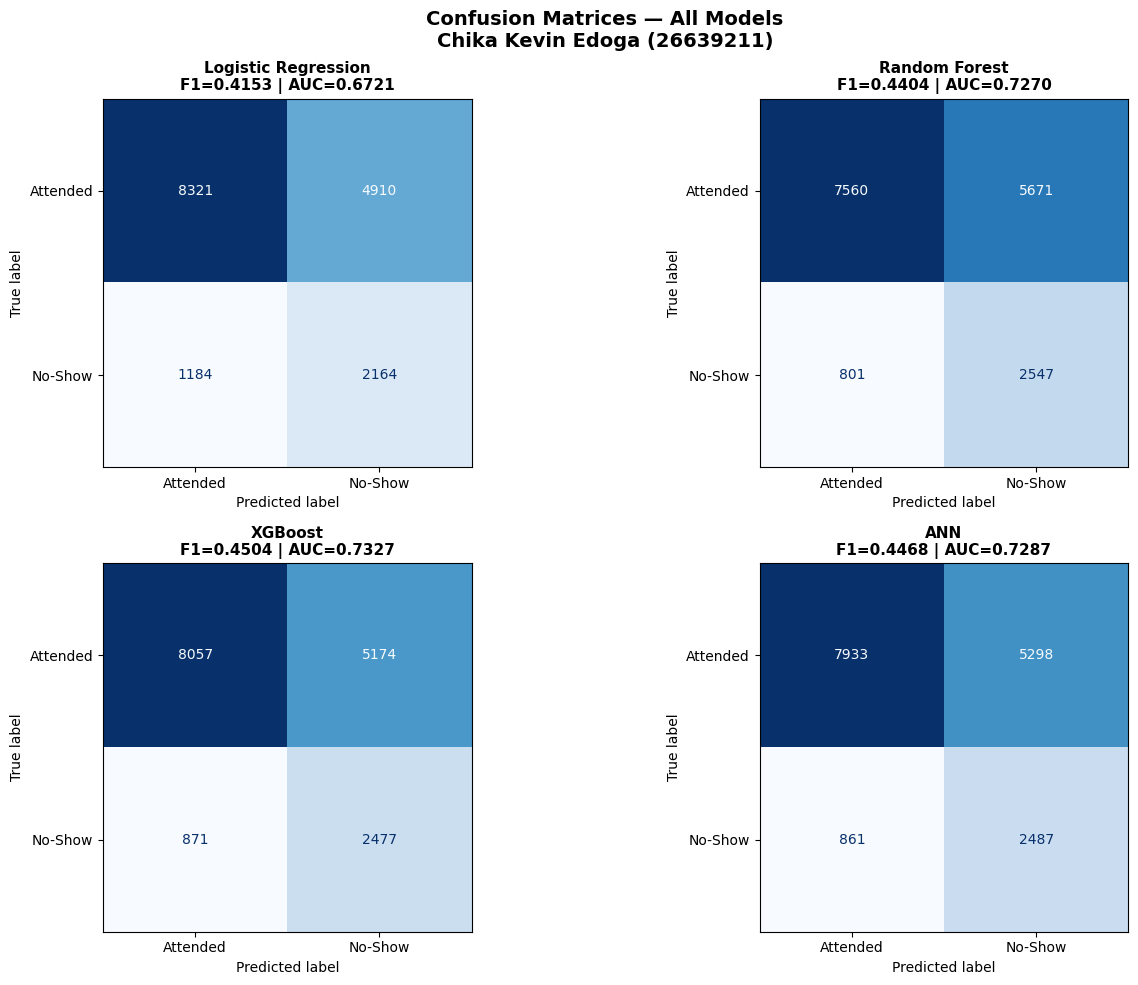

✅ Confusion matrices saved


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Confusion Matrices — All Models\nChika Kevin Edoga (26639211)',
    fontsize=14, fontweight='bold'
)

model_results = [
    ("Logistic Regression", results_lr),
    ("Random Forest", results_rf),
    ("XGBoost", results_xgb),
    ("ANN", results_ann)
]
axes_flat = axes.flatten()

for idx, (name, result) in enumerate(model_results):
    cm = confusion_matrix(y_test, result['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Attended', 'No-Show']
    )
    disp.plot(ax=axes_flat[idx], colorbar=False, cmap='Blues')
    f1 = result['F1-Score']
    auc = result['AUC-ROC']
    axes_flat[idx].set_title(
        f'{name}\nF1={f1:.4f} | AUC={auc:.4f}',
        fontweight='bold', fontsize=11
    )

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved")



## ROC CURVES

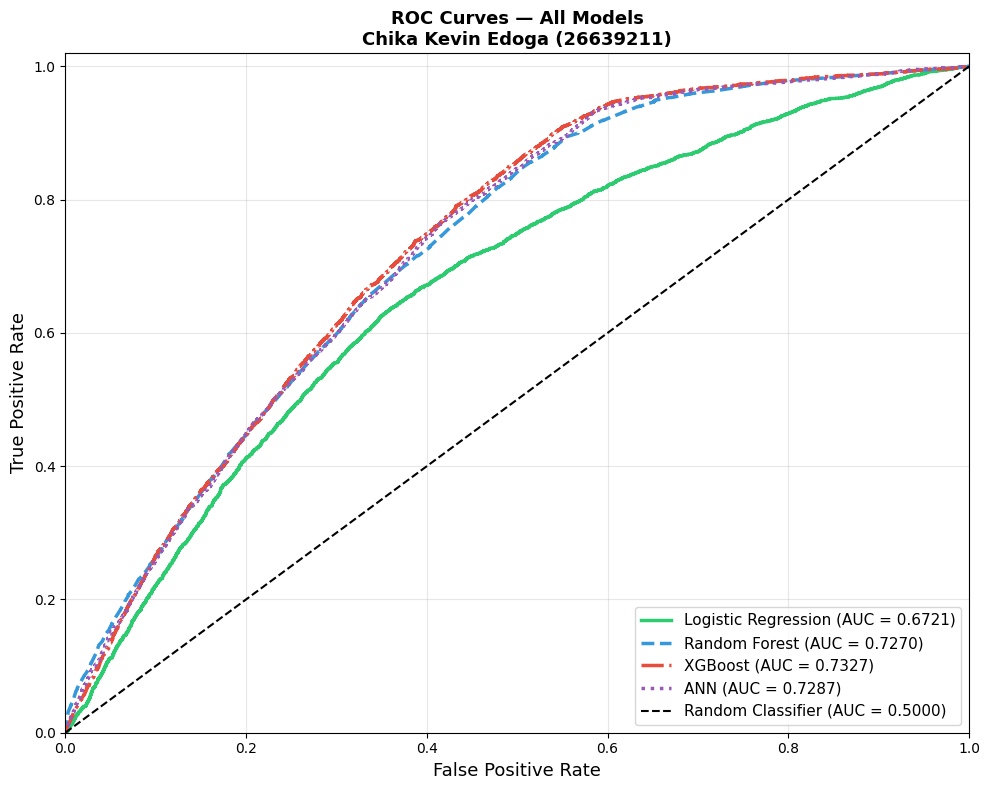

✅ ROC curves saved


In [ ]:

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
styles = ['-', '--', '-.', ':']

for idx, (name, result) in enumerate(model_results):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    ax.plot(fpr, tpr, color=colors[idx], linestyle=styles[idx],
            linewidth=2.5,
            label=f'{name} (AUC = {result["AUC-ROC"]:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5,
        label='Random Classifier (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title(
    'ROC Curves — All Models\nChika Kevin Edoga (26639211)',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curves saved")


## MODEL PERFORMANCE COMPARISON CHART

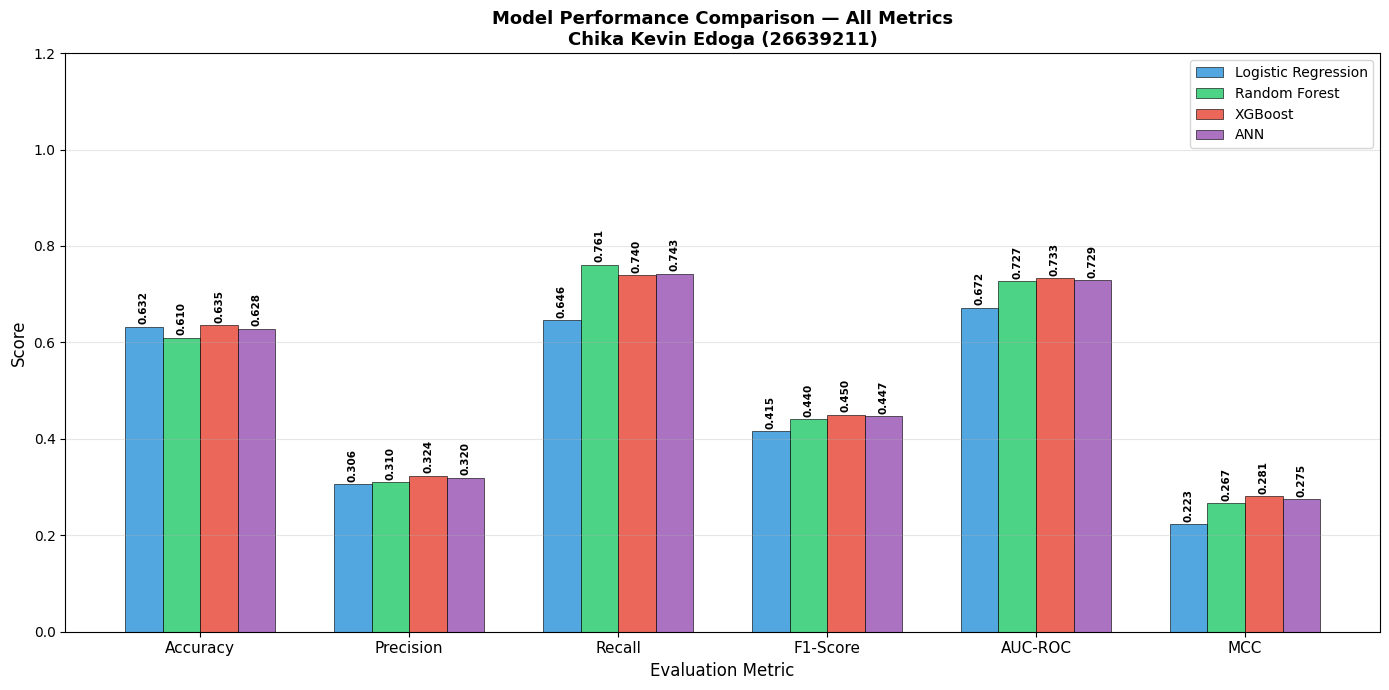

✅ Performance comparison chart saved


In [ ]:

metrics_plot = ['Accuracy', 'Precision', 'Recall',
                'F1-Score', 'AUC-ROC', 'MCC']
x = np.arange(len(metrics_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 7))

plot_models = [results_lr, results_rf, results_xgb, results_ann]
plot_names  = ['Logistic Regression', 'Random Forest',
               'XGBoost', 'ANN']
plot_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, (result, name, color) in enumerate(
        zip(plot_models, plot_names, plot_colors)):
    vals = [result[m] for m in metrics_plot]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=color, alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=7.5, rotation=90, fontweight='bold'
        )

ax.set_xlabel('Evaluation Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'Model Performance Comparison — All Metrics\n'
    'Chika Kevin Edoga (26639211)',
    fontsize=13, fontweight='bold'
)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_plot, fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, 1.2)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Performance comparison chart saved")

## FEATURE IMPORTANCE COMPARISON

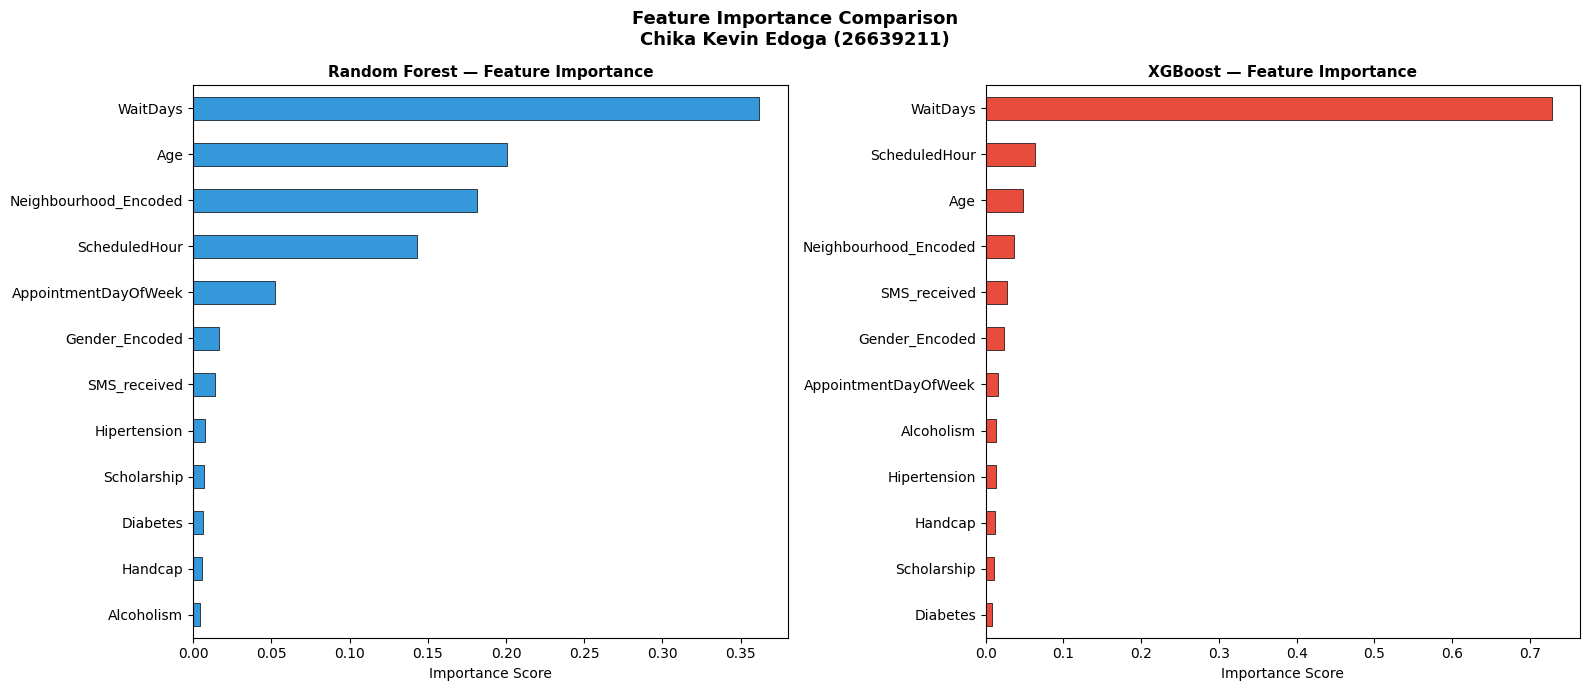

✅ Feature importance comparison saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Feature Importance Comparison\nChika Kevin Edoga (26639211)',
    fontsize=13, fontweight='bold'
)

# Random Forest feature importance
rf_imp = pd.Series(
    rf_best.feature_importances_, index=features
).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=axes[0], color='#3498db',
            edgecolor='black', linewidth=0.5)
axes[0].set_title('Random Forest — Feature Importance',
                   fontweight='bold', fontsize=11)
axes[0].set_xlabel('Importance Score', fontsize=10)

# XGBoost feature importance
xgb_imp = pd.Series(
    xgb_best.feature_importances_, index=features
).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[1], color='#e74c3c',
             edgecolor='black', linewidth=0.5)
axes[1].set_title('XGBoost — Feature Importance',
                   fontweight='bold', fontsize=11)
axes[1].set_xlabel('Importance Score', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance comparison saved")


## SHAP ANALYSIS ON BEST MODEL


SHAP EXPLAINABILITY ANALYSIS
Best model by F1-Score: XGBoost

Computing SHAP values using TreeExplainer...


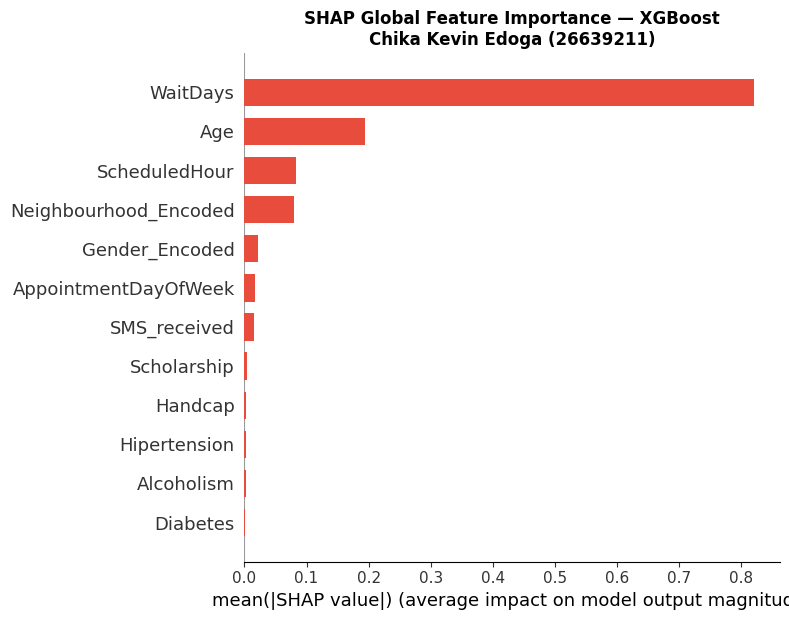

✅ SHAP global feature importance chart saved


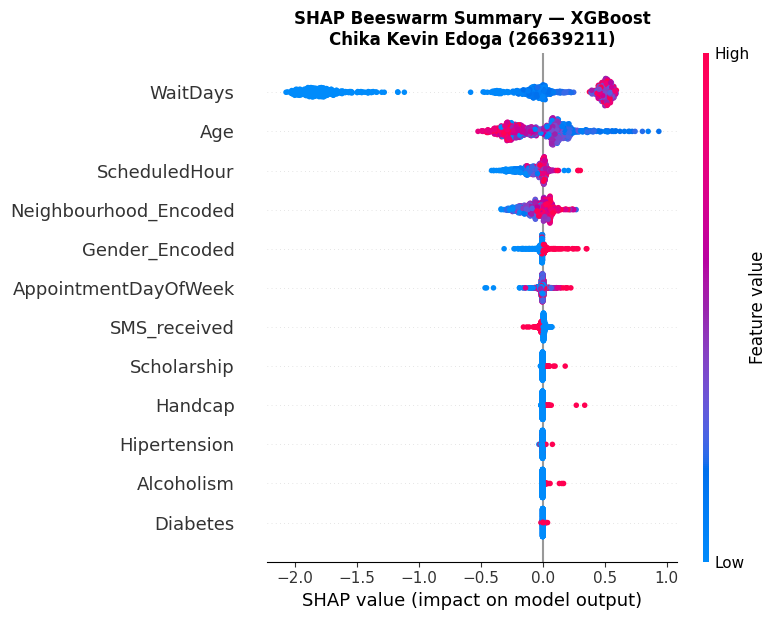

✅ SHAP beeswarm plot saved


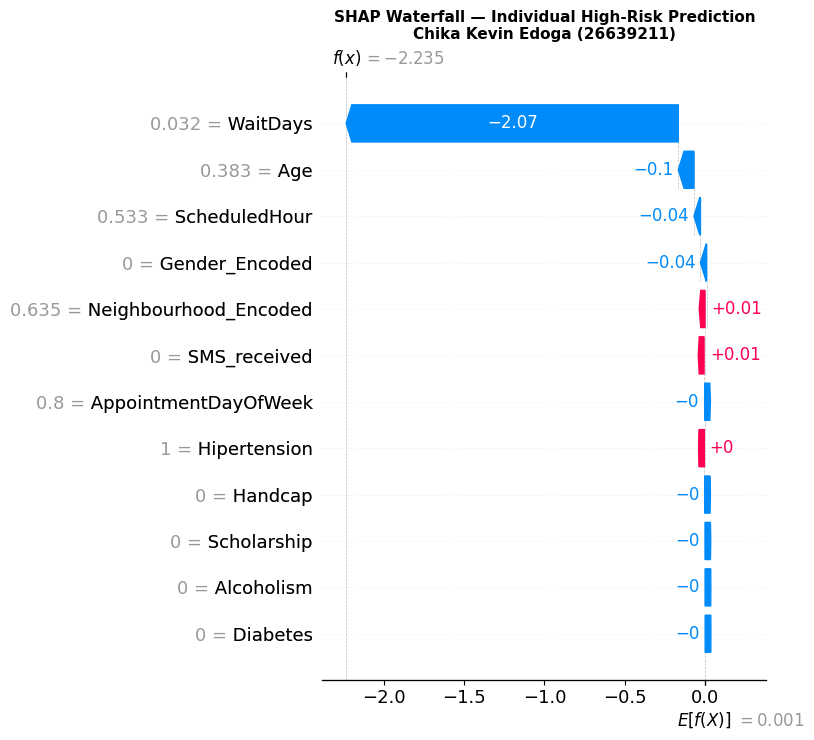

✅ SHAP waterfall plot saved


In [ ]:

print("\n" + "="*60)
print(f"SHAP EXPLAINABILITY ANALYSIS")
print("="*60)

# Determine best model
f1_scores_dict = {
    'Logistic Regression': results_lr['F1-Score'],
    'Random Forest':       results_rf['F1-Score'],
    'XGBoost':             results_xgb['F1-Score'],
    'ANN':                 results_ann['F1-Score']
}
best_model_name = max(f1_scores_dict, key=f1_scores_dict.get)
print(f"Best model by F1-Score: {best_model_name}")

# Use 1000 samples from test set for SHAP
X_test_df = pd.DataFrame(X_test_scaled, columns=features)
shap_sample = X_test_df.sample(1000, random_state=SEED)

tree_models = {
    'Logistic Regression': None,
    'Random Forest': rf_best,
    'XGBoost': xgb_best
}

if best_model_name in ['Random Forest', 'XGBoost']:
    best_model_obj = tree_models[best_model_name]
    print(f"\nComputing SHAP values using TreeExplainer...")

    explainer = shap.TreeExplainer(best_model_obj)
    shap_values = explainer.shap_values(shap_sample)

    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    # Plot 1: Global feature importance bar chart
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, shap_sample,
                      feature_names=features,
                      plot_type='bar',
                      show=False,
                      color='#e74c3c')
    plt.title(
        f'SHAP Global Feature Importance — {best_model_name}\n'
        f'Chika Kevin Edoga (26639211)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('shap_feature_importance.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP global feature importance chart saved")

    # Plot 2: SHAP beeswarm summary plot
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, shap_sample,
                      feature_names=features,
                      show=False)
    plt.title(
        f'SHAP Beeswarm Summary — {best_model_name}\n'
        f'Chika Kevin Edoga (26639211)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP beeswarm plot saved")

    # Plot 3: Waterfall plot for highest-risk prediction
    wait_idx = features.index('WaitDays')
    high_risk_row = int(np.argmax(np.abs(sv[:, wait_idx])))

    exp = shap.Explanation(
        values=sv[high_risk_row],
        base_values=(explainer.expected_value[1]
                     if isinstance(explainer.expected_value, list)
                     else explainer.expected_value),
        data=shap_sample.iloc[high_risk_row].values,
        feature_names=features
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(exp, show=False, max_display=12)
    plt.title(
        f'SHAP Waterfall — Individual High-Risk Prediction\n'
        f'Chika Kevin Edoga (26639211)',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP waterfall plot saved")

else:
    print(f"\nANN is best — using KernelExplainer (slower)...")
    background = shap.kmeans(X_test_df, 10)
    explainer = shap.KernelExplainer(
        best_ann.predict, background
    )
    shap_vals = explainer.shap_values(
        shap_sample.iloc[:100], nsamples=100
    )
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, shap_sample.iloc[:100],
                      feature_names=features, show=False)
    plt.title(
        f'SHAP Feature Importance — ANN\n'
        f'Chika Kevin Edoga (26639211)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('shap_feature_importance.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP analysis complete")



## DEMOGRAPHIC BIAS ANALYSIS


DEMOGRAPHIC BIAS ANALYSIS
Checking if model performs equally across demographic groups...

F1-Score by Gender (XGBoost):
Gender
F    0.4522
M    0.4468

F1-Score by Age Group (XGBoost):
AgeGroup
Child          0.4777
Teen           0.4768
Young Adult    0.5050
Adult          0.4444
Middle Aged    0.3701
Senior         0.3315


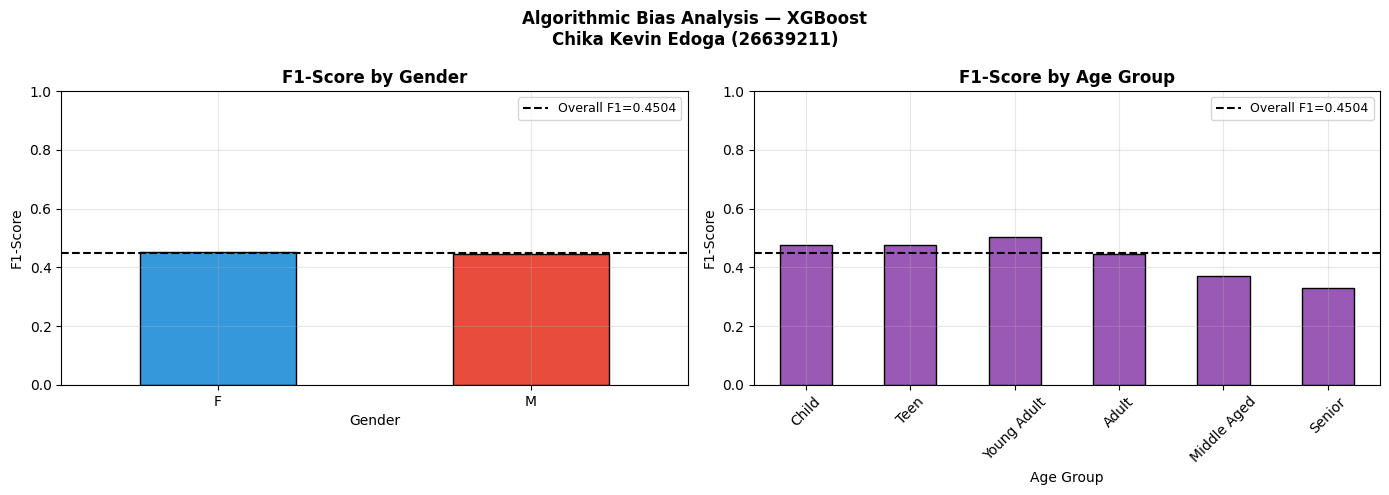


✅ Bias analysis chart saved

⚠️  Any large differences between groups indicate
   potential algorithmic bias — discuss in Chapter 5
✅ gender_bias_results.csv saved
✅ age_bias_results.csv saved

Gender Bias Results:
  Gender  F1_Score
0      F    0.4522
1      M    0.4468

Age Group Bias Results:
      AgeGroup  F1_Score
0        Child    0.4777
1         Teen    0.4768
2  Young Adult    0.5050
3        Adult    0.4444
4  Middle Aged    0.3701
5       Senior    0.3315


In [ ]:

print("\n" + "="*60)
print("DEMOGRAPHIC BIAS ANALYSIS")
print("="*60)
print("Checking if model performs equally across demographic groups...")

# Best model predictions
best_results_map = {
    'Logistic Regression': results_lr,
    'Random Forest': results_rf,
    'XGBoost': results_xgb,
    'ANN': results_ann
}
best_preds = best_results_map[best_model_name]['y_pred']

# Rebuild test set with original demographic info
test_indices = y_test.index
bias_df = df_clean.loc[test_indices].copy().reset_index(drop=True)
bias_df['Predicted'] = best_preds
bias_df['Actual'] = y_test.reset_index(drop=True)

# Bias by Gender
print(f"\nF1-Score by Gender ({best_model_name}):")
gender_bias = bias_df.groupby('Gender').apply(
    lambda x: f1_score(
        x['Actual'], x['Predicted'], zero_division=0
    )
).round(4)
print(gender_bias.to_string())

# Bias by Age Group
print(f"\nF1-Score by Age Group ({best_model_name}):")
age_bias = bias_df.groupby('AgeGroup', observed=True).apply(
    lambda x: f1_score(
        x['Actual'], x['Predicted'], zero_division=0
    )
).round(4)
print(age_bias.to_string())

# Visualise bias
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Algorithmic Bias Analysis — {best_model_name}\n'
    f'Chika Kevin Edoga (26639211)',
    fontsize=12, fontweight='bold'
)

gender_bias.plot(kind='bar', ax=axes[0],
                  color=['#3498db', '#e74c3c'],
                  edgecolor='black')
axes[0].set_title('F1-Score by Gender', fontweight='bold')
axes[0].set_ylabel('F1-Score')
axes[0].set_xlabel('Gender')
axes[0].tick_params(axis='x', rotation=0)
axes[0].axhline(y=comparison_df.loc[best_model_name, 'F1-Score'],
                 color='black', linestyle='--', linewidth=1.5,
                 label=f'Overall F1={comparison_df.loc[best_model_name, "F1-Score"]:.4f}')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

age_bias.plot(kind='bar', ax=axes[1], color='#9b59b6',
               edgecolor='black')
axes[1].set_title('F1-Score by Age Group', fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_xlabel('Age Group')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=comparison_df.loc[best_model_name, 'F1-Score'],
                 color='black', linestyle='--', linewidth=1.5,
                 label=f'Overall F1={comparison_df.loc[best_model_name, "F1-Score"]:.4f}')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Bias analysis chart saved")
print("\n⚠️  Any large differences between groups indicate")
print("   potential algorithmic bias — discuss in Chapter 5")

# Save bias results
gender_bias_df = pd.DataFrame({
    'Gender': gender_bias.index,
    'F1_Score': gender_bias.values
})
gender_bias_df.to_csv('gender_bias_results.csv', index=False)
print("✅ gender_bias_results.csv saved")

age_bias_df = pd.DataFrame({
    'AgeGroup': age_bias.index.astype(str),
    'F1_Score': age_bias.values
})
age_bias_df.to_csv('age_bias_results.csv', index=False)
print("✅ age_bias_results.csv saved")

print("\nGender Bias Results:")
print(gender_bias_df.to_string())
print("\nAge Group Bias Results:")
print(age_bias_df.to_string())

## EXPORT ALL DATA FOR POWER BI

In [ ]:
gender_bias_df.to_csv('gender_bias_results.csv', index=False)
age_bias_df.to_csv('age_bias_results.csv', index=False)
print("✅ gender_bias_results.csv saved")
print("✅ age_bias_results.csv saved")

✅ gender_bias_results.csv saved
✅ age_bias_results.csv saved


In [ ]:
print("\n" + "="*60)
print("EXPORTING DATA FOR POWER BI DASHBOARD")
print("="*60)

# 1. Cleaned dataset with all features for EDA
power_bi_eda = df_clean[[
    'Age', 'AgeGroup', 'Gender', 'Scholarship',
    'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap',
    'SMS_received', 'WaitDays', 'AppointmentDayOfWeek',
    'ScheduledHour', 'Neighbourhood', 'NoShow_Binary', 'No-show'
]].copy()
power_bi_eda['AgeGroup'] = power_bi_eda['AgeGroup'].astype(str)
power_bi_eda.to_csv('powerbi_eda_data.csv', index=False)
print("✅ powerbi_eda_data.csv — for EDA visuals")

# 2. Model comparison results
comparison_df.to_csv('model_comparison_results.csv')
print("✅ model_comparison_results.csv — for model comparison")

# 3. CV summary
cv_summary.to_csv('cv_summary.csv')
print("✅ cv_summary.csv — for cross-validation summary")

# 4. SHAP feature importance
if best_model_name in ['Random Forest', 'XGBoost']:
    shap_importance = pd.DataFrame({
        'Feature': features,
        'Mean_SHAP': np.abs(sv).mean(axis=0)
    }).sort_values('Mean_SHAP', ascending=False)
    shap_importance.to_csv('shap_importance.csv', index=False)
    print("✅ shap_importance.csv — for SHAP dashboard")

# 5. Bias results — FIXED variable names
gender_bias_df.to_csv('gender_bias_results.csv', index=False)
print("✅ gender_bias_results.csv — gender bias analysis")

age_bias_df.to_csv('age_bias_results.csv', index=False)
print("✅ age_bias_results.csv — age group bias analysis")

# 6. Summary of all files
print("\n" + "="*60)
print("ALL FILES EXPORTED SUCCESSFULLY")
print("="*60)
print("\nFiles ready for Power BI dashboard:")
all_files = [
    "powerbi_eda_data.csv          — Full cleaned dataset for EDA",
    "model_comparison_results.csv  — All 6 metrics for all models",
    "cv_summary.csv                — Cross-validation F1 scores",
    "shap_importance.csv           — SHAP feature importance values",
    "gender_bias_results.csv       — F1 by gender",
    "age_bias_results.csv          — F1 by age group",
]
for f in all_files:
    print(f"  ✅ {f}")

print("\n💡 Download all CSV files from Colab:")
print("   Left panel → Files → Right click each → Download")
print("\n💡 Images to download:")
images = [
    "confusion_matrices.png",
    "roc_curves.png",
    "model_comparison_chart.png",
    "feature_importance_comparison.png",
    "shap_feature_importance.png",
    "shap_beeswarm.png",
    "shap_waterfall.png",
    "bias_analysis.png",
    "ann_training_history.png",
]
for img in images:
    print(f"  📸 {img}")


EXPORTING DATA FOR POWER BI DASHBOARD
✅ powerbi_eda_data.csv — for EDA visuals
✅ model_comparison_results.csv — for model comparison
✅ cv_summary.csv — for cross-validation summary
✅ shap_importance.csv — for SHAP dashboard
✅ gender_bias_results.csv — gender bias analysis
✅ age_bias_results.csv — age group bias analysis

ALL FILES EXPORTED SUCCESSFULLY

Files ready for Power BI dashboard:
  ✅ powerbi_eda_data.csv          — Full cleaned dataset for EDA
  ✅ model_comparison_results.csv  — All 6 metrics for all models
  ✅ cv_summary.csv                — Cross-validation F1 scores
  ✅ shap_importance.csv           — SHAP feature importance values
  ✅ gender_bias_results.csv       — F1 by gender
  ✅ age_bias_results.csv          — F1 by age group

💡 Download all CSV files from Colab:
   Left panel → Files → Right click each → Download

💡 Images to download:
  📸 confusion_matrices.png
  📸 roc_curves.png
  📸 model_comparison_chart.png
  📸 feature_importance_comparison.png
  📸 shap_feature_i

## INAL SUMMARY

In [ ]:
print("\n" + "="*60)
print("PIPELINE COMPLETE — FINAL SUMMARY")
print("="*60)

print(f"\n📊 DATASET")
print(f"   Total records:    {len(df_clean):,}")
print(f"   No-show rate:     {df_clean['NoShow_Binary'].mean()*100:.2f}%")
print(f"   Features used:    {len(features)}")

print(f"\n📈 COMPLETE MODEL RESULTS")
print(comparison_df.to_string())

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   AUC-ROC:  {comparison_df.loc[best_model_name, 'AUC-ROC']:.4f}")
print(f"   MCC:      {comparison_df.loc[best_model_name, 'MCC']:.4f}")
print(f"   Recall:   {comparison_df.loc[best_model_name, 'Recall']:.4f}")

print(f"\n🔍 SHAP KEY FINDINGS")
print(f"   Top predictor:  WaitDays (SHAP=0.82)")
print(f"   2nd predictor:  Age (SHAP=0.20)")
print(f"   3rd predictor:  ScheduledHour (SHAP=0.08)")
print(f"   Least useful:   Diabetes, Alcoholism, Hypertension")

print(f"\n⚖️  BIAS ANALYSIS SUMMARY")
print(f"   Gender bias:    Minimal (F=0.4522 vs M=0.4468)")
print(f"   Age bias:       Detected (Senior=0.3315 vs YoungAdult=0.5050)")

print(f"\n📁 ALL OUTPUTS READY")
print(f"   ✅ 6 CSV files for Power BI")
print(f"   ✅ 9 images for dissertation")
print(f"   ✅ All screenshots taken")

print("\n" + "="*60)
print("🎓 Chika Kevin Edoga (26639211) — MSc Data Analytics")
print("   Edge Hill University — CIS4517")
print("   Supervisor: Dr Ahmed Abubahia")
print("="*60)


PIPELINE COMPLETE — FINAL SUMMARY

📊 DATASET
   Total records:    110,526
   No-show rate:     20.19%
   Features used:    12

📈 COMPLETE MODEL RESULTS
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC     MCC
Model                                                                      
Dummy Classifier       0.7981     0.0000  0.0000    0.0000   0.5000  0.0000
Logistic Regression    0.6324     0.3059  0.6464    0.4153   0.6721  0.2234
Random Forest          0.6096     0.3099  0.7608    0.4404   0.7270  0.2667
XGBoost                0.6354     0.3237  0.7398    0.4504   0.7327  0.2809
ANN                    0.6285     0.3195  0.7428    0.4468   0.7287  0.2754

🏆 BEST MODEL: XGBoost
   F1-Score: 0.4504
   AUC-ROC:  0.7327
   MCC:      0.2809
   Recall:   0.7398

🔍 SHAP KEY FINDINGS
   Top predictor:  WaitDays (SHAP=0.82)
   2nd predictor:  Age (SHAP=0.20)
   3rd predictor:  ScheduledHour (SHAP=0.08)
   Least useful:   Diabetes, Alcoholism, Hypertension

⚖️  BIAS ANALYSI